In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

# Adjust if your notebook is somewhere else
# If notebook is in Battery_Analysis/notebooks:
PROJECT_ROOT = Path("..")  # Battery_Analysis/
RUN_ROOT = PROJECT_ROOT / "outputs" / "stage4mix_39173858"

RUN_ROOT.exists(), RUN_ROOT


(True, WindowsPath('../outputs/stage4mix_39173858'))

In [2]:
import re

def parse_task_trial(folder_name: str):
    """
    folder_name example: task_99_trial_49
    returns (task=99, trial=49) or (None, None) if not matching
    """
    m = re.match(r"task_(\d+)_trial_(\d+)$", folder_name)
    if not m:
        return None, None
    return int(m.group(1)), int(m.group(2))


In [3]:
def read_all_stage4_summaries(run_root: Path, modes=("real", "synth_free", "synth_locked")) -> pd.DataFrame:
    rows = []

    for mode in modes:
        base = run_root / mode
        if not base.exists():
            print(f"[warn] missing mode folder: {base}")
            continue

        # find all stage4_summary.json under this mode
        for summary_path in base.rglob("stage4_summary.json"):
            # summary_path is like:
            # .../real/task_99_trial_49/stage4_summary.json
            run_folder = summary_path.parent
            task, trial = parse_task_trial(run_folder.name)

            # If your structure is deeper (rare), still try to find task/trial in parents
            if task is None:
                for p in run_folder.parents:
                    task, trial = parse_task_trial(p.name)
                    if task is not None:
                        break

            try:
                data = json.loads(summary_path.read_text(encoding="utf-8"))
            except Exception as e:
                rows.append({
                    "mode": mode,
                    "task": task,
                    "trial": trial,
                    "path": str(summary_path),
                    "ok": False,
                    "err": repr(e),
                })
                continue

            rows.append({
                "mode": mode,
                "task": task,
                "trial": trial,
                "path": str(summary_path),
                "ok": True,
                "best_mse": float(data.get("best_mse", float("nan"))),
                "best_post_max": float(data.get("best_post_max", float("nan"))),
                "runs_completed": int(data.get("runs_completed", 0)),
                "total_configs": int(data.get("total_configs", 0)),
                "trial_start": int(data.get("trial_start", -1)),
                "trial_end_exclusive": int(data.get("trial_end_exclusive", -1)),
            })

    df = pd.DataFrame(rows)
    return df

df = read_all_stage4_summaries(RUN_ROOT)
df.head(), df.shape


(   mode  task  trial                                               path    ok  \
 0  real     0      0  ..\outputs\stage4mix_39173858\real\task_0_tria...  True   
 1  real    10     10  ..\outputs\stage4mix_39173858\real\task_10_tri...  True   
 2  real    11     11  ..\outputs\stage4mix_39173858\real\task_11_tri...  True   
 3  real    12     12  ..\outputs\stage4mix_39173858\real\task_12_tri...  True   
 4  real    13     13  ..\outputs\stage4mix_39173858\real\task_13_tri...  True   
 
    best_mse  best_post_max  runs_completed  total_configs  trial_start  \
 0  0.001148       0.138339               8             16            0   
 1  0.001008       0.138284              11             16           10   
 2  0.001014       0.136353              10             16           11   
 3  0.000984       0.136686              14             16           12   
 4  0.004356       0.429647               8             16           13   
 
    trial_end_exclusive  
 0                    1  
 1

In [4]:
# Keep only successful parses
df_ok = df[df["ok"] == True].copy()

# Drop weird/failed numeric entries
df_ok = df_ok.dropna(subset=["best_mse"])

# Sort by mse (lower is better)
df_ok_sorted = df_ok.sort_values(["best_mse", "best_post_max"], ascending=True).reset_index(drop=True)

df_ok_sorted.head(20)


,mode,task,trial,path,ok,best_mse,best_post_max,runs_completed,total_configs,trial_start,trial_end_exclusive
0,synth_locked,78,28,..\outputs\stage4mix_39173858\synth_locked\tas...,True,6.214560e-10,0.000168,1,1,28,29
1,synth_locked,87,37,..\outputs\stage4mix_39173858\synth_locked\tas...,True,6.221510e-10,0.000166,1,1,37,38
2,synth_locked,51,1,..\outputs\stage4mix_39173858\synth_locked\tas...,True,6.411853e-10,0.000168,1,1,1,2
3,synth_locked,92,42,..\outputs\stage4mix_39173858\synth_locked\tas...,True,6.419873e-10,0.000166,1,1,42,43
4,synth_locked,67,17,..\outputs\stage4mix_39173858\synth_locked\tas...,True,6.432458e-10,0.000168,1,1,17,18
5,synth_locked,71,21,..\outputs\stage4mix_39173858\synth_locked\tas...,True,6.721707e-10,0.000177,1,1,21,22
6,synth_locked,91,41,..\outputs\stage4mix_39173858\synth_locked\tas...,True,6.727687e-10,0.000183,1,1,41,42
7,synth_locked,61,11,..\outputs\stage4mix_39173858\synth_locked\tas...,True,6.809006e-10,0.000176,1,1,11,12
8,synth_locked,85,35,..\outputs\stage4mix_39173858\synth_locked\tas...,True,7.098927e-10,0.000195,1,1,35,36
9,synth_locked,88,38,..\outputs\stage4mix_39173858\synth_locked\tas...,True,7.193018e-10,0.000195,1,1,38,39


In [5]:
print("Total summaries parsed:", len(df_ok_sorted))

if len(df_ok_sorted):
    print("\n=== GLOBAL BEST ===")
    print(df_ok_sorted.loc[0, ["mode", "task", "trial", "best_mse", "best_post_max", "runs_completed", "total_configs", "path"]])

print("\n=== BEST PER MODE ===")
for mode, g in df_ok_sorted.groupby("mode"):
    best = g.iloc[0]
    print(f"\n[{mode}]")
    print(best[["mode", "task", "trial", "best_mse", "best_post_max", "runs_completed", "total_configs"]].to_dict())
    print("path:", best["path"])


Total summaries parsed: 150

=== GLOBAL BEST ===
mode                                                   synth_locked
task                                                             78
trial                                                            28
best_mse                                                        0.0
best_post_max                                              0.000168
runs_completed                                                    1
total_configs                                                     1
path              ..\outputs\stage4mix_39173858\synth_locked\tas...
Name: 0, dtype: object

=== BEST PER MODE ===

[real]
{'mode': 'real', 'task': 35, 'trial': 35, 'best_mse': 0.0009834119246628326, 'best_post_max': 0.13659029983482274, 'runs_completed': 11, 'total_configs': 16}
path: ..\outputs\stage4mix_39173858\real\task_35_trial_35\stage4_summary.json

[synth_free]
{'mode': 'synth_free', 'task': 141, 'trial': 41, 'best_mse': 1.3952784533253106e-09, 'best_post_max': 0

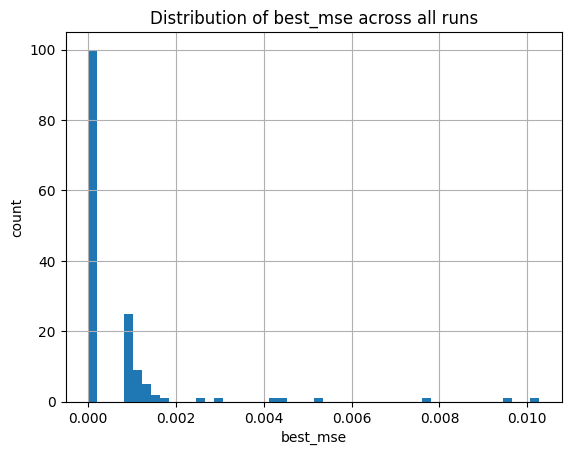

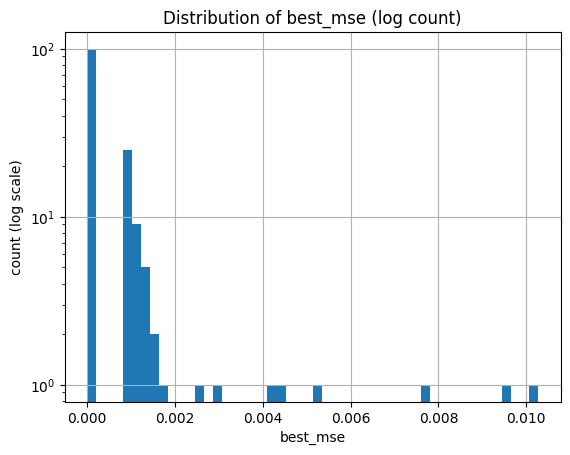

In [6]:
plt.figure()
plt.hist(df_ok_sorted["best_mse"].values, bins=50)
plt.xlabel("best_mse")
plt.ylabel("count")
plt.title("Distribution of best_mse across all runs")
plt.grid(True)
plt.show()

plt.figure()
plt.hist(df_ok_sorted["best_mse"].values, bins=50)
plt.yscale("log")  # often useful if you have many good + many terrible runs
plt.xlabel("best_mse")
plt.ylabel("count (log scale)")
plt.title("Distribution of best_mse (log count)")
plt.grid(True)
plt.show()


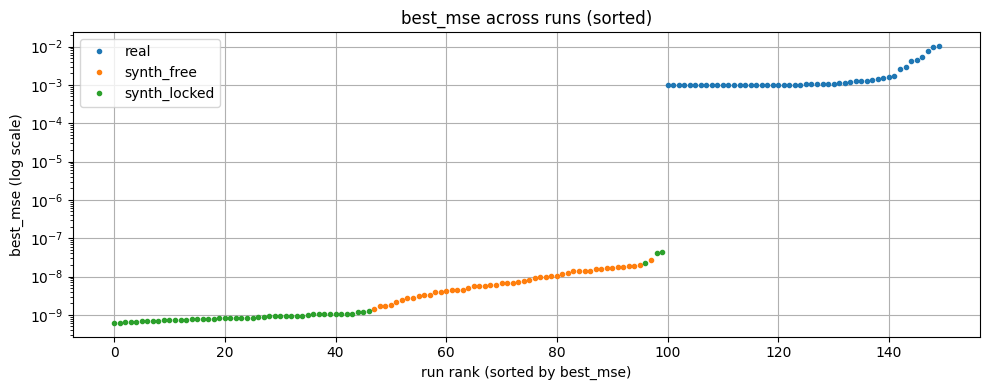

In [7]:
plt.figure(figsize=(10, 4))
for mode, g in df_ok_sorted.groupby("mode"):
    plt.plot(g.index, g["best_mse"].values, marker=".", linestyle="none", label=mode)

plt.yscale("log")  # usually the right choice
plt.xlabel("run rank (sorted by best_mse)")
plt.ylabel("best_mse (log scale)")
plt.title("best_mse across runs (sorted)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
